# Tarea de Clustering — Taller de Proyecto, Diplomado en Ingeniería y Ciencia de Datos (Grupo 4)

**Objetivo.** Aplicar clustering para caracterizar establecimientos educacionales de nivel
socioeconómico bajo/medio-bajo, siguiendo estrictamente la rúbrica de la tarea (componente
Clustering, 30%).

**Pregunta de investigación.**
> ¿Qué caracteriza a las escuelas de nivel socioeconómico bajo que alcanzan mejores logros de
> aprendizaje que otras escuelas en condiciones similares?

**Diseño del análisis.** Los grupos se forman **solo con variables de proceso escolar**
(`convivencia`, `asistencia_2m`, `promedio_estandarizado_genero`). Quedan fuera del
agrupamiento:

- las **variables objetivo** (`prom_mate2m_rbd`, `target_bin`), para que la separación por
  logro no sea impuesta por construcción;
- las **variables de contexto** (`ive_media`, `pct_tramo_avanzado_mas`), por instrucción
  explícita.

Ambos bloques se usan después, solo para interpretar los grupos. Esto tiene una ventaja
directa para la pregunta: al no agrupar por nivel socioeconómico, se puede **verificar** si
los grupos resultantes quedan en condiciones socioeconómicas comparables y, en ese caso,
comparar su logro "a igualdad de condiciones".

Este notebook cubre únicamente los puntos exigidos por la rúbrica:
- Explicación de algoritmos usados, datos usados y ajuste de parámetros (10%).
- Visualización de grupos, revisión de casos en cada grupo e interpretación de grupos (20%).


In [20]:
# Entorno reproducible: versiones de librerías y semilla fija
import sys, subprocess

print("Versión de Python:", sys.version)
print()

freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
print(freeze)

SEED = 42
print(f"Semilla fija (random_state) usada en todo el notebook: {SEED}")


Versión de Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]

aif360==0.6.1
anyio==4.14.2
argon2-cffi==25.1.0
argon2-cffi-bindings==26.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.3.0
attrs==26.1.0
babel==2.18.0
beautifulsoup4==4.15.0
bleach==6.4.0
certifi==2026.4.22
cffi==2.1.1
charset-normalizer==3.4.7
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cramjam==2.11.0
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
defusedxml==0.7.1
executing==2.2.1
fastjsonschema==2.22.2
fastparquet==2026.5.0
fonttools==4.62.1
fqdn==1.5.1
fsspec==2026.6.0
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.13
ipykernel==7.2.0
ipython==9.13.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.9
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.15.0
jsonpointer==3.1.1
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.1
jupyter-lsp==2.3.1
jupyter_builder==1.2.2
jupyter_client==8.8.0
jupyt

## Carga de datos

**Nota sobre el nombre del archivo.** La consigna especifica la ruta
`datos\base_tareas_filtradas.parquet` (plural). Ese archivo no existe en la carpeta `datos`.
El archivo existente con el nombre más cercano es `base_tareas_filtrada.parquet` (singular),
generado en el notebook de referencia `EDAyPreprocesamiento_01.ipynb` (celda 161) como
subconjunto de trabajo de `base_tareas.parquet`, con las categóricas etiquetadas y el target
binario reconstruido. Se confirmó con el usuario el uso de este archivo singular en reemplazo
del nombre en plural que no existe. La celda siguiente verifica de todas formas la existencia
del archivo antes de continuar; si no lo encuentra, imprime el error y detiene la ejecución.


In [21]:
import os
import pandas as pd

RUTA_DATOS = r"C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4\datos\base_tareas_filtrada.parquet"
CARPETA_SALIDA = r"C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4"

if not os.path.exists(RUTA_DATOS):
    print(f"ERROR: archivo no encontrado en {RUTA_DATOS}. Detener ejecución.")
    raise SystemExit("Archivo no encontrado; ejecución detenida.")

df = pd.read_parquet(RUTA_DATOS)
print(f"Archivo cargado correctamente: {RUTA_DATOS}")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")


Archivo cargado correctamente: C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4\datos\base_tareas_filtrada.parquet
Dimensiones: 1429 filas x 10 columnas


In [22]:
df.head()

,rbd,depe,cod_reg_rbd,convivencia,ive_media,promedio_estandarizado_genero,asistencia_2m,pct_tramo_avanzado_mas,target_bin,prom_mate2m_rbd
0,40126,Municipal,4,75.0,0.922,0.051435,0.774291,35.294118,0,233.0
1,6853,Municipal,14,71.0,1.000,0.200372,0.796071,30.769231,0,213.0
2,26372,Part. subvencionado,13,79.0,0.948,-0.239126,0.875246,34.285714,1,259.0
3,22436,Part. subvencionado,10,73.0,0.949,0.034020,0.852913,28.971963,0,241.0
4,12117,Municipal,13,73.0,0.877,0.290069,0.783134,37.037037,0,222.0


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1429 entries, 0 to 1428
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   rbd                            1429 non-null   int64  
 1   depe                           1429 non-null   str    
 2   cod_reg_rbd                    1429 non-null   int64  
 3   convivencia                    1429 non-null   float64
 4   ive_media                      1429 non-null   float64
 5   promedio_estandarizado_genero  1429 non-null   float64
 6   asistencia_2m                  1429 non-null   float64
 7   pct_tramo_avanzado_mas         1429 non-null   float64
 8   target_bin                     1429 non-null   int64  
 9   prom_mate2m_rbd                1429 non-null   float64
dtypes: float64(6), int64(3), str(1)
memory usage: 131.2 KB


In [24]:
df.describe(include="all")

,rbd,depe,cod_reg_rbd,convivencia,ive_media,promedio_estandarizado_genero,asistencia_2m,pct_tramo_avanzado_mas,target_bin,prom_mate2m_rbd
count,1429.000000,1429,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000
unique,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Part. subvencionado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,11088.809657,NaN,9.311407,75.231631,0.889199,-0.003880,0.860050,32.296772,0.247726,238.006298
std,8588.351231,NaN,3.900587,4.388705,0.060964,0.233254,0.055295,17.564251,0.431843,24.903834
min,1.000000,NaN,1.000000,62.000000,0.593000,-0.994859,0.518314,0.000000,0.000000,189.000000
25%,4262.000000,NaN,6.000000,72.000000,0.854000,-0.148863,0.826728,19.047619,0.000000,220.000000
50%,9666.000000,NaN,9.000000,75.000000,0.897000,0.010127,0.866825,33.333333,0.000000,233.000000
75%,15832.000000,NaN,13.000000,78.000000,0.934000,0.144152,0.900519,45.454545,0.000000,251.000000


### Columnas disponibles y selección de variables para clustering

Columnas disponibles en `df`: `rbd`, `depe`, `cod_reg_rbd`, `convivencia`, `ive_media`,
`promedio_estandarizado_genero`, `asistencia_2m`, `pct_tramo_avanzado_mas`, `target_bin`,
`prom_mate2m_rbd`.

**La selección de variables fue indicada explícitamente por el usuario**, de modo que no
corresponde aplicar la regla de prioridad automática de la consigna (que rige solo "si
automatizas la selección sin confirmación humana"). Se deja constancia de las decisiones y de
en qué se apartan de esa regla:

| Bloque | Columnas | Uso | Motivo |
|---|---|---|---|
| Proceso escolar | `convivencia`, `asistencia_2m`, `promedio_estandarizado_genero` | **Agrupamiento** | Únicas variables de proceso de la base; son lo que la pregunta pide caracterizar |
| Objetivo | `prom_mate2m_rbd`, `target_bin` | Solo interpretación | Son las variables de resultado; usarlas para agrupar produciría separación por logro por construcción |
| Contexto | `ive_media`, `pct_tramo_avanzado_mas` | Solo interpretación | Excluidas del agrupamiento por instrucción explícita del usuario |
| Identificadores | `rbd`, `cod_reg_rbd`, `depe` | Solo descripción | `rbd` es llave; `cod_reg_rbd` y `depe` son categóricas cuyo peso en una distancia euclidiana sería arbitrario |

**Desviación respecto de la regla de prioridad de la consigna, declarada:** esa regla situaba
`ive_media` como indicador socioeconómico y `pct_tramo_avanzado_mas` como recursos
disponibles dentro del espacio de agrupamiento. Por indicación del usuario ambas quedan fuera.
No se trata de una omisión: pasan a cumplir el papel de **variables de control**, y en la
sección de interpretación se verifica con ellas si los grupos son comparables en condiciones
socioeconómicas.

**Variables de clustering (3):** `["convivencia", "asistencia_2m", "promedio_estandarizado_genero"]`


In [25]:
VARS = ["convivencia", "asistencia_2m", "promedio_estandarizado_genero"]
CONTEXTO = ["ive_media", "pct_tramo_avanzado_mas"]
RESULTADO = ["prom_mate2m_rbd", "target_bin"]

print("Variables de clustering:      ", VARS)
print("Variables de contexto (no agrupan):", CONTEXTO)
print("Variables objetivo (no agrupan):   ", RESULTADO)
print("\nValores faltantes en las variables de clustering:")
print(df[VARS].isna().sum())


Variables de clustering:       ['convivencia', 'asistencia_2m', 'promedio_estandarizado_genero']
Variables de contexto (no agrupan): ['ive_media', 'pct_tramo_avanzado_mas']
Variables objetivo (no agrupan):    ['prom_mate2m_rbd', 'target_bin']

Valores faltantes en las variables de clustering:
convivencia                      0
asistencia_2m                    0
promedio_estandarizado_genero    0
dtype: int64


# Explicación de algoritmos y datos

## Datos usados

- **Fuente:** `base_tareas_filtrada.parquet`, 1.429 establecimientos, ya restringidos por
  construcción a GSE bajo y medio-bajo (`ive_media` va de 0,59 a 1,00, con media 0,89).
- **Unidad de análisis:** el establecimiento (`rbd`), no el estudiante.
- **Preprocesamiento previo, reutilizado del notebook de referencia** (se cita, no se
  re-ejecuta, porque depende de dataframes intermedios que no están en esta base):
  en `EDAyPreprocesamiento_01.ipynb`, **celda 143**, se consolidan 6 fuentes por `rbd` y se
  eliminan las filas con no respuesta con
  `base_tareas = base_tareas.dropna().reset_index(drop=True)`; en la **celda 161** se deriva
  `base_tareas_filtrada` re-etiquetando `depe` con
  `map_depe2 = {1: "Municipal", 2: "Part. subvencionado", 3: "Part. pagado", 4: "SLEP"}` y
  reconstruyendo `target_bin = (base_tareas_filtrada["prom_mate2m_rbd"] >= 252).astype(int)`.
  Por eso la base no tiene valores perdidos (verificado en la celda anterior).
- **Variables de agrupamiento:** las 3 de proceso escolar, todas continuas. Sus correlaciones
  mutuas son bajas (la mayor es 0,29 entre `convivencia` y `asistencia_2m`), de modo que
  aportan información parcialmente independiente y ninguna domina el espacio por redundancia.

## Algoritmos usados

Se prueban dos algoritmos, ambos apropiados para variables continuas estandarizadas:

- **K-Means.** Minimiza la suma de distancias euclidianas al cuadrado de cada punto al
  centroide de su grupo. Es apropiado aquí porque las 3 variables son continuas, la muestra es
  de tamaño moderado (n=1.429) y entrega centroides directamente interpretables en la escala
  original de cada variable, que es lo que la pregunta necesita para describir perfiles.
  Parámetros clave: `n_clusters` (rango probado: 2 a 8), `n_init=25` (reinicios para evitar
  mínimos locales) y `random_state=42`.
- **Agglomerative Clustering (linkage de Ward).** Construye la partición jerárquicamente,
  fusionando en cada paso los grupos que menos aumentan la varianza intra-cluster. No depende
  de inicialización aleatoria, por lo que sirve de contraste: si ambos coincidieran, la
  partición sería atribuible a la estructura de los datos y no al método. Parámetros clave:
  `n_clusters` (rango probado: 2 a 8) y `linkage="ward"` (métrica euclidiana, consistente con
  K-Means).

No se usa DBSCAN: requiere fijar `eps` sobre un espacio estandarizado donde las densidades son
similares entre zonas, y su salida habitual en estos casos es un único grupo grande más ruido,
que no permite construir los perfiles comparables que pide la rúbrica.


## Preprocesamiento para clustering

Las tres variables están en escalas distintas: `convivencia` ronda 60-90, `asistencia_2m` va
de 0 a 1 y `promedio_estandarizado_genero` es un z-score centrado en 0. Como ambos algoritmos
usan distancia euclidiana, sin estandarizar `convivencia` dominaría por completo la distancia.
Se aplica `StandardScaler` (media 0, desviación estándar 1), único paso necesario: la base no
tiene valores perdidos ni requiere codificación categórica, porque las 3 variables ya son
continuas.


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

preprocessing_pipeline = Pipeline(steps=[("scaler", StandardScaler())])
X = preprocessing_pipeline.fit_transform(df[VARS])

RUTA_PIPELINE = os.path.join(CARPETA_SALIDA, "preprocessing_pipeline.joblib")
joblib.dump(preprocessing_pipeline, RUTA_PIPELINE)
print(f"Pipeline de preprocesamiento guardado en: {RUTA_PIPELINE}")
print(f"Forma de X (matriz estandarizada): {X.shape}")


Pipeline de preprocesamiento guardado en: C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4\preprocessing_pipeline.joblib
Forma de X (matriz estandarizada): (1429, 3)


# Ajuste de parámetros y métricas

Para cada algoritmo se prueba `n_clusters` (k) de 2 a 8 y se calculan tres métricas internas
sobre la misma matriz estandarizada `X`:

- **Silhouette** (rango [-1, 1], mayor es mejor): cohesión dentro del grupo frente a
  separación respecto del grupo vecino más cercano.
- **Davies-Bouldin** (menor es mejor): razón entre dispersión intra-cluster y distancia entre
  centroides.
- **Calinski-Harabasz** (mayor es mejor): razón entre dispersión entre grupos y dispersión
  intra-grupo.

La búsqueda es manual y no por `GridSearchCV`, porque son métricas de evaluación interna no
supervisada y no encajan como `scoring` de un estimador supervisado. Es reproducible: mismo
`X`, mismo rango de k, `n_init=25` y `random_state=42` fijos.

**Regla de decisión, fijada antes de mirar los resultados:** se adopta la combinación
(algoritmo, k) que **maximiza el silhouette**, por ser la métrica acotada y de lectura más
directa. Las otras dos se reportan como corroboración.


In [27]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

K_RANGE = range(2, 9)
resultados = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=25, random_state=SEED).fit(X)
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)
    for nombre, labels in [("KMeans", km.labels_), ("Agglomerative", agg.labels_)]:
        resultados.append({
            "algoritmo": nombre, "k": k,
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
        })

tabla_metricas = pd.DataFrame(resultados)
tabla_metricas.round(4)


,algoritmo,k,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,2,0.2568,1.4438,548.1074
1,Agglomerative,2,0.2142,1.5707,439.6242
2,KMeans,3,0.2398,1.3107,514.1591
3,Agglomerative,3,0.1942,1.4213,414.3859
4,KMeans,4,0.2310,1.2319,491.5556
5,Agglomerative,4,0.1715,1.4849,368.0737
6,KMeans,5,0.2318,1.2273,459.6966
7,Agglomerative,5,0.1645,1.5094,351.1176
8,KMeans,6,0.2306,1.1835,445.9400
9,Agglomerative,6,0.1522,1.3903,339.3759


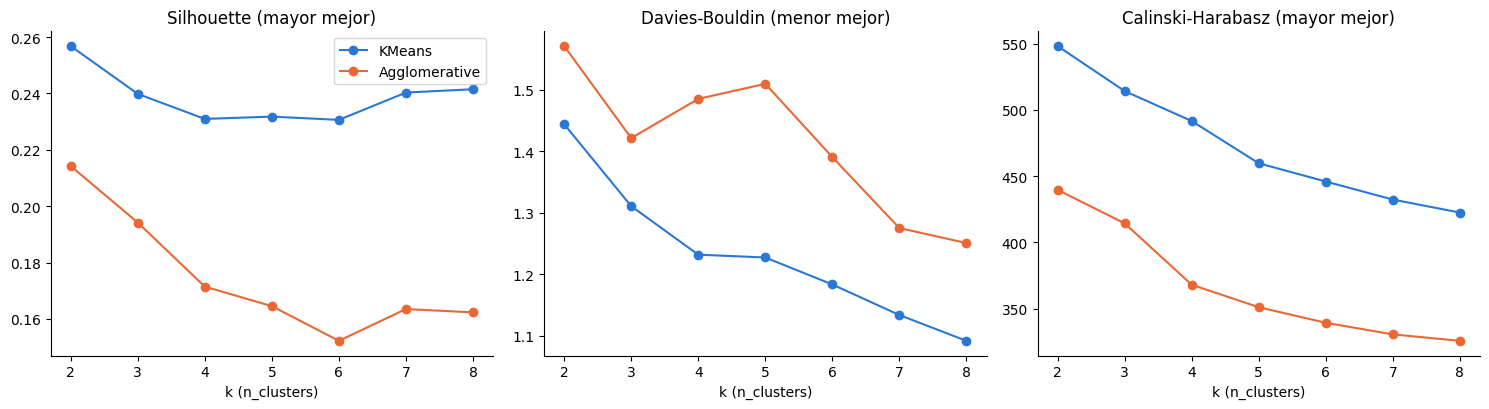

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, met, tit in zip(
        axes,
        ["silhouette", "davies_bouldin", "calinski_harabasz"],
        ["Silhouette (mayor mejor)", "Davies-Bouldin (menor mejor)", "Calinski-Harabasz (mayor mejor)"]):
    for nombre, color in [("KMeans", "#2a78d6"), ("Agglomerative", "#eb6834")]:
        sub = tabla_metricas[tabla_metricas["algoritmo"] == nombre]
        ax.plot(sub["k"], sub[met], marker="o", color=color, label=nombre)
    ax.set_title(tit); ax.set_xlabel("k (n_clusters)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend()
plt.tight_layout(); plt.show()


In [29]:
mejor = tabla_metricas.loc[tabla_metricas["silhouette"].idxmax()]
print("Máximo global de silhouette:")
print(f"  algoritmo:         {mejor['algoritmo']}")
print(f"  k:                 {mejor['k']}")
print(f"  silhouette:        {mejor['silhouette']:.4f}")
print(f"  davies_bouldin:    {mejor['davies_bouldin']:.4f}")
print(f"  calinski_harabasz: {mejor['calinski_harabasz']:.4f}")
print()
print("Mínimo de Davies-Bouldin:", tabla_metricas.loc[tabla_metricas['davies_bouldin'].idxmin(), ['algoritmo','k']].to_dict())
print("Máximo de Calinski-Harabasz:", tabla_metricas.loc[tabla_metricas['calinski_harabasz'].idxmax(), ['algoritmo','k']].to_dict())


Máximo global de silhouette:
  algoritmo:         KMeans
  k:                 2
  silhouette:        0.2568
  davies_bouldin:    1.4438
  calinski_harabasz: 548.1074

Mínimo de Davies-Bouldin: {'algoritmo': 'KMeans', 'k': 8}
Máximo de Calinski-Harabasz: {'algoritmo': 'KMeans', 'k': 2}


## Decisión de k y algoritmo final

Aplicando la regla fijada de antemano, el máximo global de silhouette se obtiene con
**K-Means, k=2** (silhouette ≈ 0,257). **Calinski-Harabasz coincide**: su máximo también está
en K-Means k=2 (≈ 548,1). Agglomerative queda por debajo de K-Means en silhouette en todo el
rango (máximo ≈ 0,214, también en k=2). Se adopta **K-Means con k=2** como modelo final.

**Discrepancia declarada.** Davies-Bouldin no acompaña: su mínimo está en k=8 (≈ 1,09) y
mejora de forma casi monótona al aumentar k, comportamiento habitual de esta métrica, que
tiende a premiar particiones más finas. Adoptar k=8 daría grupos pequeños y solapados, sin
perfiles interpretables. Se mantiene la regla declarada (silhouette, corroborado por
Calinski-Harabasz) y se deja constancia de la discrepancia en vez de omitirla.

**Sobre la fuerza de la estructura.** Un silhouette de 0,257 indica estructura **moderada, no
fuerte**: los datos se describen mejor como un gradiente de calidad de procesos que como dos
poblaciones nítidamente separadas. Los grupos deben leerse como tendencias promedio, con
solapamiento entre ellos, no como categorías cerradas.


In [30]:
K_FINAL = 2
modelo_clustering = KMeans(n_clusters=K_FINAL, n_init=25, random_state=SEED).fit(X)
df["cluster"] = modelo_clustering.labels_

print("Tamaño de cada cluster:")
print(df["cluster"].value_counts().sort_index())
print()
print(f"Silhouette:        {silhouette_score(X, df['cluster']):.4f}")
print(f"Davies-Bouldin:    {davies_bouldin_score(X, df['cluster']):.4f}")
print(f"Calinski-Harabasz: {calinski_harabasz_score(X, df['cluster']):.4f}")

# Contraste con el segundo algoritmo, con el mismo k
from sklearn.metrics import adjusted_rand_score
agg_final = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward").fit(X)
print(f"\nTamaños con Agglomerative (k=2): {pd.Series(agg_final.labels_).value_counts().sort_index().tolist()}")
print(f"Adjusted Rand Index K-Means vs Agglomerative: {adjusted_rand_score(modelo_clustering.labels_, agg_final.labels_):.3f}")

RUTA_MODELO = os.path.join(CARPETA_SALIDA, "modelo_clustering.joblib")
joblib.dump(modelo_clustering, RUTA_MODELO)
print(f"\nModelo final guardado en: {RUTA_MODELO}")


Tamaño de cada cluster:
cluster
0    640
1    789
Name: count, dtype: int64

Silhouette:        0.2568
Davies-Bouldin:    1.4438
Calinski-Harabasz: 548.1074

Tamaños con Agglomerative (k=2): [872, 557]
Adjusted Rand Index K-Means vs Agglomerative: 0.411

Modelo final guardado en: C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4\modelo_clustering.joblib


El Adjusted Rand Index entre ambos algoritmos con k=2 es 0,411: **coincidencia parcial**.
Los dos métodos identifican una división del mismo tipo, pero ubican la frontera en lugares
distintos (872 y 557 con Agglomerative, frente a 640 y 789 con K-Means). Es lo esperable en un
gradiente sin separación nítida, y se reporta como limitación de la partición, no como
validación de ella.


# Visualización de grupos

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED).fit(X)
coords = pca.transform(X)
print("Varianza explicada por componente:", pca.explained_variance_ratio_.round(3))
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum().round(3))
print("\nCargas de cada variable en los componentes:")
pd.DataFrame(pca.components_.T, index=VARS, columns=["PC1", "PC2"]).round(3)


Varianza explicada por componente: [0.444 0.32 ]
Varianza explicada acumulada: 0.764

Cargas de cada variable en los componentes:


,PC1,PC2
convivencia,0.669,0.225
asistencia_2m,0.666,0.242
promedio_estandarizado_genero,-0.330,0.944


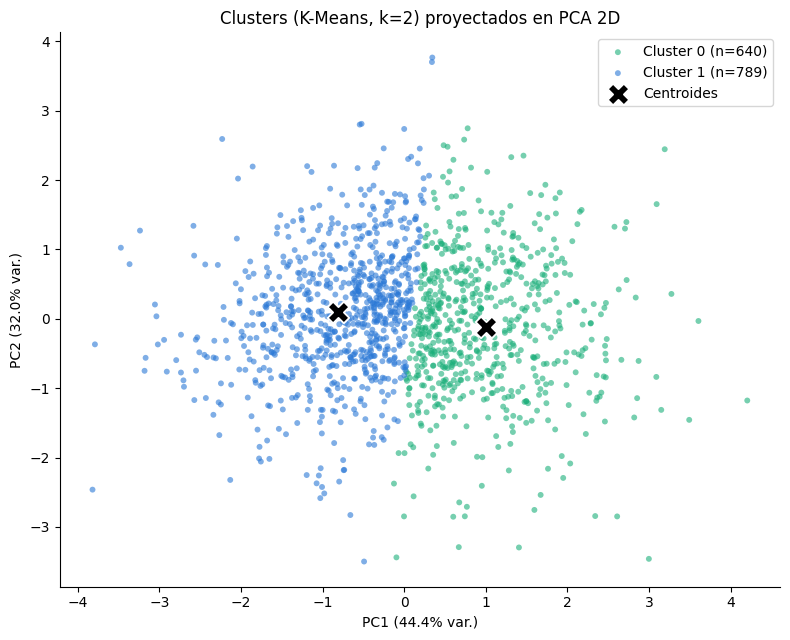

Figura guardada en: C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4\cluster_pca.png


In [32]:
COLORES = {0: "#1baf7a", 1: "#2a78d6"}
NOMBRES = {0: "Cluster 0", 1: "Cluster 1"}

fig, ax = plt.subplots(figsize=(8, 6.5))
for c in sorted(df["cluster"].unique()):
    m = df["cluster"] == c
    ax.scatter(coords[m, 0], coords[m, 1], s=18, alpha=0.6, color=COLORES[c],
               edgecolors="none", label=f"{NOMBRES[c]} (n={m.sum()})")

cen = pca.transform(modelo_clustering.cluster_centers_)
ax.scatter(cen[:, 0], cen[:, 1], marker="X", s=240, color="black",
           edgecolors="white", linewidth=1.3, zorder=5, label="Centroides")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("Clusters (K-Means, k=2) proyectados en PCA 2D")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

RUTA_PCA = os.path.join(CARPETA_SALIDA, "cluster_pca.png")
plt.savefig(RUTA_PCA, dpi=150); plt.show()
print(f"Figura guardada en: {RUTA_PCA}")


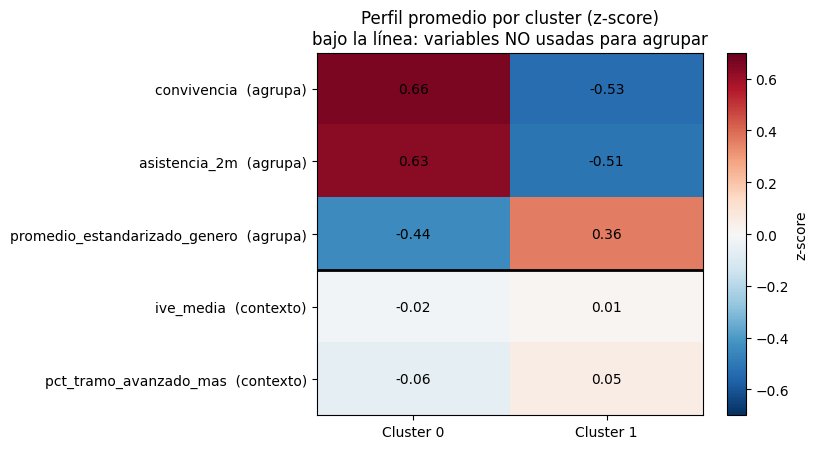

Figura guardada en: C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4\cluster_heatmap.png


In [33]:
# Mapa de calor: media por grupo de las variables de clustering y de las de contexto.
# Las de contexto se incluyen para mostrar visualmente si los grupos quedaron o no
# comparables en condiciones socioeconómicas. Todo en z-score, para hacer comparables
# variables de escalas distintas dentro de un mismo mapa.
VARS_MAPA = VARS + CONTEXTO
z = (df[VARS_MAPA] - df[VARS_MAPA].mean()) / df[VARS_MAPA].std()
z["cluster"] = df["cluster"]
perfil_z = z.groupby("cluster")[VARS_MAPA].mean()

etiquetas = [f"{v}  (agrupa)" for v in VARS] + [f"{v}  (contexto)" for v in CONTEXTO]

fig, ax = plt.subplots(figsize=(8.2, 4.6))
im = ax.imshow(perfil_z.T.values, cmap="RdBu_r", vmin=-0.7, vmax=0.7, aspect="auto")
ax.set_xticks(range(len(perfil_z))); ax.set_xticklabels([NOMBRES[c] for c in perfil_z.index])
ax.set_yticks(range(len(VARS_MAPA))); ax.set_yticklabels(etiquetas)
for i in range(perfil_z.shape[0]):
    for j in range(perfil_z.shape[1]):
        ax.text(i, j, f"{perfil_z.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
# línea que separa las variables que agrupan de las que no
ax.axhline(len(VARS) - 0.5, color="black", lw=2)
ax.set_title("Perfil promedio por cluster (z-score)\nbajo la línea: variables NO usadas para agrupar")
fig.colorbar(im, ax=ax, label="z-score")
plt.tight_layout()

RUTA_HEATMAP = os.path.join(CARPETA_SALIDA, "cluster_heatmap.png")
plt.savefig(RUTA_HEATMAP, dpi=150); plt.show()
print(f"Figura guardada en: {RUTA_HEATMAP}")


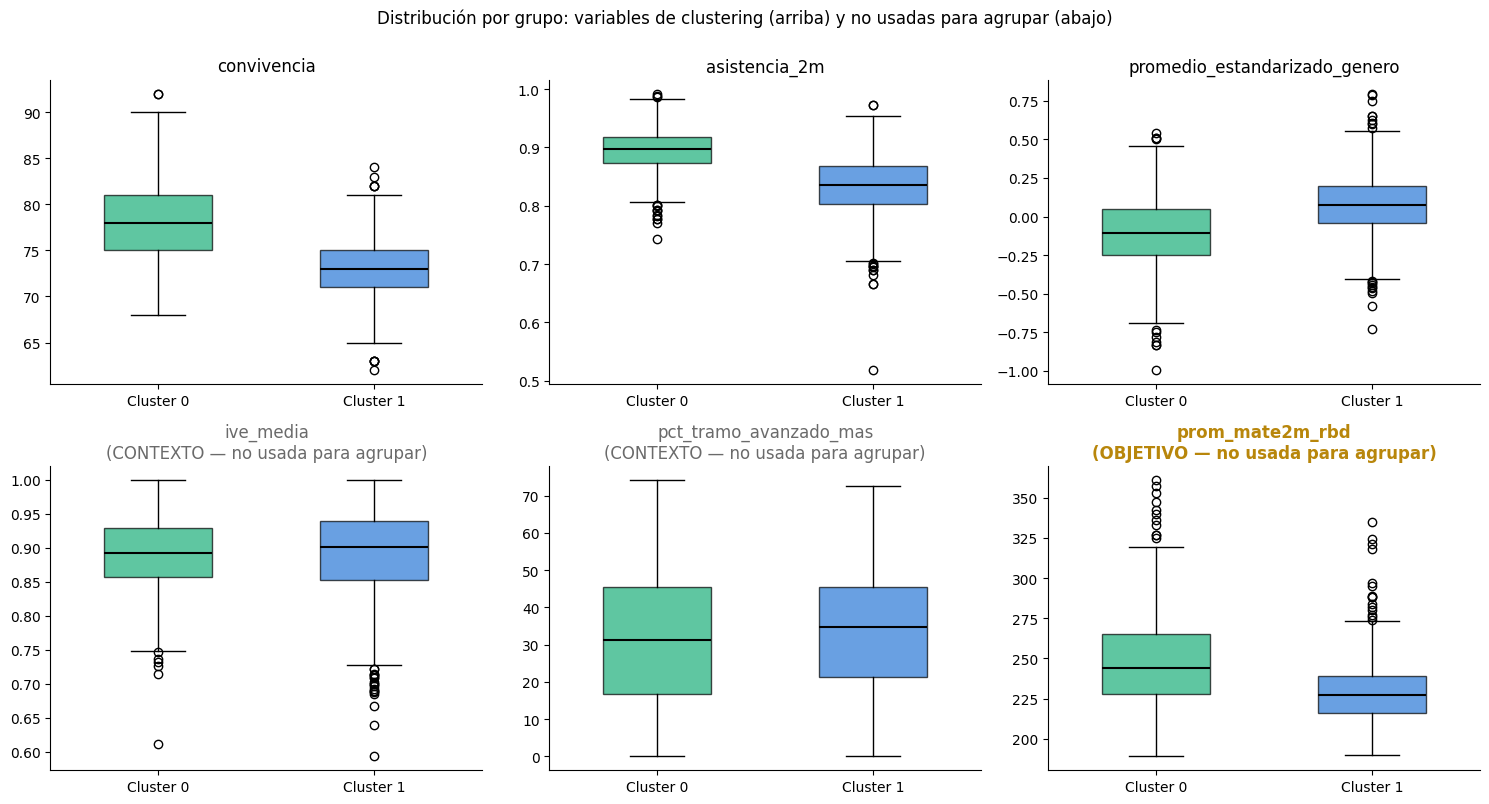

Figura guardada en: C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4\cluster_boxplots.png


In [34]:
# Boxplots: variables de clustering (fila 1) y variables no usadas para agrupar (fila 2)
paneles = VARS + ["ive_media", "pct_tramo_avanzado_mas", "prom_mate2m_rbd"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, var in zip(axes.ravel(), paneles):
    datos = [df.loc[df["cluster"] == c, var] for c in sorted(df["cluster"].unique())]
    cajas = ax.boxplot(datos, patch_artist=True, widths=0.5,
                       tick_labels=[NOMBRES[c] for c in sorted(df["cluster"].unique())],
                       medianprops=dict(color="black", lw=1.5))
    for caja, c in zip(cajas["boxes"], sorted(df["cluster"].unique())):
        caja.set_facecolor(COLORES[c]); caja.set_alpha(0.7)
    if var in VARS:
        ax.set_title(var)
    elif var == "prom_mate2m_rbd":
        ax.set_title(f"{var}\n(OBJETIVO — no usada para agrupar)",
                     color="#b8860b", fontweight="bold")
    else:
        ax.set_title(f"{var}\n(CONTEXTO — no usada para agrupar)", color="#6a6a6a")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Distribución por grupo: variables de clustering (arriba) y no usadas para agrupar (abajo)", y=1.0)
plt.tight_layout()

RUTA_BOXPLOT = os.path.join(CARPETA_SALIDA, "cluster_boxplots.png")
plt.savefig(RUTA_BOXPLOT, dpi=150); plt.show()
print(f"Figura guardada en: {RUTA_BOXPLOT}")


**Lectura de las visualizaciones.** En el PCA, PC1 (44,4% de la varianza) carga casi por
igual en `convivencia` (+0,669) y `asistencia_2m` (+0,666): es un eje de **calidad de los
procesos escolares**, y es el que separa a los dos grupos. PC2 (32,0%) está dominado por
`promedio_estandarizado_genero` (+0,944): es un eje de creencias de género, en el que los
grupos se distinguen mucho menos. Los dos componentes suman **76,4%** de la varianza, de modo
que la figura 2D representa fielmente el espacio de agrupamiento. Las dos nubes se separan
sobre el eje horizontal, sin frontera vacía entre ellas: coherente con el silhouette moderado.

El mapa de calor muestra el resultado más importante para la pregunta: **sobre la línea**, las
tres variables de proceso se oponen con fuerza entre grupos; **bajo la línea**, `ive_media` y
`pct_tramo_avanzado_mas` son casi idénticas en ambos (z-scores cercanos a 0). Es decir, los
grupos difieren en procesos pero **no** en condiciones socioeconómicas. Los boxplots muestran
lo mismo en las escalas originales, y el último panel agrega la distribución del resultado, que
no participó en el agrupamiento.


# Revisión de casos por grupo

Para cada cluster se muestran los **5 casos más representativos**: los establecimientos con
**menor distancia euclidiana al centroide de su grupo**, calculada en el mismo espacio
estandarizado `X` con el que se ajustó el modelo. Una distancia pequeña significa que el
establecimiento está cerca del perfil promedio del grupo en las 3 variables de proceso
simultáneamente, es decir, es un caso típico y no un caso de frontera.

Se incluyen `ive_media`, `pct_tramo_avanzado_mas` y `prom_mate2m_rbd` en la tabla **solo como
información de contexto**: ninguna intervino en el cálculo de la distancia ni en la formación
de los grupos.


In [35]:
import numpy as np

dist_centroide = np.linalg.norm(X - modelo_clustering.cluster_centers_[modelo_clustering.labels_], axis=1)
df["dist_centroide"] = dist_centroide

COLS_CASO = ["rbd", "depe", "cod_reg_rbd"] + VARS + CONTEXTO + ["prom_mate2m_rbd", "dist_centroide"]

for c in sorted(df["cluster"].unique()):
    print(f"\n=== {NOMBRES[c]} — 5 casos más representativos (n del grupo = {(df['cluster']==c).sum()}) ===")
    casos = df.loc[df["cluster"] == c, COLS_CASO].nsmallest(5, "dist_centroide").reset_index(drop=True)
    # se redondean solo las columnas numéricas: 'depe' es de tipo str y no admite round()
    display(casos.round({col: 3 for col in casos.select_dtypes("number").columns}))



=== Cluster 0 — 5 casos más representativos (n del grupo = 640) ===


,rbd,depe,cod_reg_rbd,convivencia,asistencia_2m,promedio_estandarizado_genero,ive_media,pct_tramo_avanzado_mas,prom_mate2m_rbd,dist_centroide
0,31161,Part. subvencionado,13,78.0,0.891,-0.119,0.881,5.263,268.0,0.093
1,9375,Part. subvencionado,13,78.0,0.902,-0.097,0.882,16.667,233.0,0.134
2,13314,Part. subvencionado,4,78.0,0.897,-0.170,0.893,42.647,295.0,0.275
3,6119,Part. subvencionado,9,77.0,0.893,-0.132,0.964,17.857,260.0,0.276
4,763,Part. subvencionado,4,79.0,0.904,-0.132,0.828,15.385,250.0,0.285



=== Cluster 1 — 5 casos más representativos (n del grupo = 789) ===


,rbd,depe,cod_reg_rbd,convivencia,asistencia_2m,promedio_estandarizado_genero,ive_media,pct_tramo_avanzado_mas,prom_mate2m_rbd,dist_centroide
0,4925,Municipal,8,73.0,0.836,0.104,0.948,58.333,241.0,0.134
1,110,SLEP,1,73.0,0.841,0.048,0.764,41.667,234.0,0.215
2,3940,Municipal,16,73.0,0.819,0.077,0.958,46.552,249.0,0.224
3,22655,Municipal,10,74.0,0.834,0.079,0.872,41.667,216.0,0.255
4,8497,Municipal,13,73.0,0.831,0.015,0.733,42.623,242.0,0.281


**Lectura de los casos.** Los casos típicos del **Cluster 0** tienen convivencia de 77 a 79,
asistencia sobre 0,89 y creencias de género bajo la media (−0,10 a −0,17); los cinco son
particulares subvencionados. Los del **Cluster 1** tienen convivencia de 73 a 74, asistencia
entre 0,82 y 0,84 y creencias de género sobre la media; predominan municipales.

Dos observaciones que se desprenden directamente de estas tablas:

1. **Las variables de contexto no ordenan a los casos típicos.** Dentro de los cinco casos
   representativos del Cluster 0, `pct_tramo_avanzado_mas` va de 5,3% a 42,6% e `ive_media` de
   0,828 a 0,964. Como no participaron en el agrupamiento, varían libremente dentro del grupo.
2. **La pertenencia al grupo no determina el resultado individual.** Entre los casos típicos
   del Cluster 0 hay establecimientos de 233 y de 295 puntos; entre los del Cluster 1, de 216 y
   de 249. Las diferencias de la sección siguiente son de promedios, con amplio solapamiento.


# Interpretación de grupos (vinculada a la pregunta de investigación)

In [36]:
# Perfil por grupo: variables de agrupamiento, de contexto y de resultado
tabla_perfil = df.groupby("cluster")[VARS].mean().round(3)
tabla_perfil["n"] = df.groupby("cluster").size()
tabla_perfil["% del total"] = (tabla_perfil["n"] / len(df) * 100).round(1)
tabla_perfil["CONTEXTO: ive_media"] = df.groupby("cluster")["ive_media"].mean().round(3)
tabla_perfil["CONTEXTO: pct_tramo_avanzado_mas"] = df.groupby("cluster")["pct_tramo_avanzado_mas"].mean().round(2)
tabla_perfil["RESULTADO: puntaje medio"] = df.groupby("cluster")["prom_mate2m_rbd"].mean().round(1)
tabla_perfil["RESULTADO: mediana"] = df.groupby("cluster")["prom_mate2m_rbd"].median()
tabla_perfil["RESULTADO: desv. est."] = df.groupby("cluster")["prom_mate2m_rbd"].std().round(1)
tabla_perfil["RESULTADO: % sobre 252"] = (df.groupby("cluster")["target_bin"].mean() * 100).round(1)
tabla_perfil


,convivencia,asistencia_2m,promedio_estandarizado_genero,n,% del total,CONTEXTO: ive_media,CONTEXTO: pct_tramo_avanzado_mas,RESULTADO: puntaje medio,RESULTADO: mediana,RESULTADO: desv. est.,RESULTADO: % sobre 252
cluster,,,,,,,,,,,
0,78.112,0.895,-0.107,640,44.8,0.888,31.18,248.4,244.0,27.5,41.6
1,72.895,0.832,0.080,789,55.2,0.890,33.20,229.6,227.0,18.7,11.2


In [37]:
print("¿Son los grupos comparables en condiciones socioeconómicas? Distribución de ive_media:")
display(df.groupby("cluster")["ive_media"].describe().round(3))

print("\nComposición por dependencia (proporción dentro de cada cluster):")
display(pd.crosstab(df["cluster"], df["depe"], normalize="index").round(3))

print("\nCorrelación con el resultado (Pearson), variables de agrupamiento y de contexto:")
display(df[VARS + CONTEXTO + ["prom_mate2m_rbd"]].corr()["prom_mate2m_rbd"]
        .drop("prom_mate2m_rbd").round(3).to_frame("r con prom_mate2m_rbd"))


¿Son los grupos comparables en condiciones socioeconómicas? Distribución de ive_media:


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,640.0,0.888,0.056,0.611,0.857,0.892,0.929,1.0
1,789.0,0.890,0.065,0.593,0.852,0.901,0.939,1.0



Composición por dependencia (proporción dentro de cada cluster):


depe,Municipal,Part. subvencionado,SLEP
cluster,,,
0,0.267,0.681,0.052
1,0.475,0.414,0.110



Correlación con el resultado (Pearson), variables de agrupamiento y de contexto:


,r con prom_mate2m_rbd
convivencia,0.364
asistencia_2m,0.329
promedio_estandarizado_genero,-0.240
ive_media,-0.141
pct_tramo_avanzado_mas,-0.033


## Perfil de los dos grupos

**Cluster 0 — procesos escolares más favorables (n=640; 44,8%).**
`convivencia` 78,1 · `asistencia_2m` 0,895 · `promedio_estandarizado_genero` −0,107.
Dependencia: 68,1% particular subvencionado, 26,7% municipal, 5,2% SLEP.
**Resultado (no usado para agrupar):** 248,4 puntos de media, mediana 244,0; **41,6%** supera
el umbral de 252 puntos.

**Cluster 1 — procesos escolares más débiles (n=789; 55,2%).**
`convivencia` 72,9 · `asistencia_2m` 0,832 · `promedio_estandarizado_genero` +0,080.
Dependencia: 47,5% municipal, 41,4% particular subvencionado, 11,0% SLEP.
**Resultado (no usado para agrupar):** 229,6 puntos de media, mediana 227,0; **11,2%** supera
el umbral.

## El contraste "en condiciones similares"

Este es el punto central del diseño. Como el nivel socioeconómico **no** se usó para formar los
grupos, se puede verificar si quedaron comparables en esa dimensión, y quedaron:

| | Cluster 0 | Cluster 1 |
|---|---|---|
| `ive_media` media | 0,888 | 0,890 |
| `ive_media` mediana | 0,892 | 0,901 |
| `pct_tramo_avanzado_mas` media | 31,2% | 33,2% |
| **Puntaje medio** | **248,4** | **229,6** |
| **% sobre 252 puntos** | **41,6%** | **11,2%** |

Los dos grupos tienen **prácticamente la misma vulnerabilidad socioeconómica** (0,888 vs.
0,890; una diferencia de 0,002, despreciable frente a una desviación estándar de ~0,06) y una
dotación docente formal muy similar (31,2% vs. 33,2%). Y sin embargo difieren en **18,9 puntos**
de promedio y en **30,4 puntos porcentuales** en la proporción que supera el umbral.

## Respuesta a la pregunta de investigación

Entre escuelas de NSE bajo y medio-bajo **en condiciones socioeconómicas equivalentes**, las
que alcanzan mejores logros se caracterizan por sus **procesos escolares**: mayor asistencia
(0,895 vs. 0,832), mejor convivencia escolar (78,1 vs. 72,9) y creencias de género menos
estereotipadas entre sus estudiantes (−0,107 vs. +0,080). Las correlaciones directas con el
puntaje ordenan igual esos rasgos: `convivencia` (r = +0,364) y `asistencia_2m` (r = +0,329)
son las asociaciones más fuertes de la base, seguidas de `promedio_estandarizado_genero`
(r = −0,240). En cambio las dos variables de contexto son las más débiles: `ive_media`
(r = −0,141) y `pct_tramo_avanzado_mas` (r = −0,033, prácticamente nula, coherente con la
celda 180 del notebook de referencia, donde su importancia por permutación era indistinguible
de cero).

**Advertencia sobre lo que no queda controlado.** Los grupos están igualados en IVE, pero
**no** en dependencia: el Cluster 0 es 68,1% particular subvencionado y el Cluster 1 es 47,5%
municipal. Parte de la brecha de logro puede corresponder a diferencias de sector y no a los
procesos escolares medidos. El diseño empareja en nivel socioeconómico, no en todo lo demás.

**Conclusión.** Con el nivel socioeconómico igualado entre grupos (IVE 0,888 vs. 0,890), lo que
distingue a las escuelas de NSE bajo con mejores logros son sus procesos internos: asistencia y
convivencia más altas y creencias de género menos estereotipadas, con una brecha de 18,9 puntos
y de 30,4 puntos porcentuales sobre el umbral. Ni la vulnerabilidad socioeconómica ni la
proporción de docentes en tramos avanzados diferencian a los grupos, y son las variables con
menor asociación con el puntaje (r = −0,141 y r = −0,033). La partición es moderada (silhouette
0,257; ARI 0,411 entre ambos algoritmos): describe un gradiente, no dos poblaciones separadas,
y la brecha es de promedios, con fuerte solapamiento individual (desviaciones de 27,5 y 18,7
puntos dentro de cada grupo). El resultado es **descriptivo y correlacional**: la composición
por dependencia difiere entre grupos y no se controló, por lo que no puede atribuirse causalidad
a los procesos escolares.


## Entregables

- Notebook ejecutable: `tarea_clustering.ipynb`
- `preprocessing_pipeline.joblib`
- `modelo_clustering.joblib`
- `cluster_pca.png`
- `cluster_heatmap.png`
- `cluster_boxplots.png`

He seguido estrictamente la rúbrica; no se han añadido análisis fuera de la rúbrica; no se han
inventado variables ni resultados.


In [38]:
archivos_esperados = {
    "preprocessing_pipeline.joblib": RUTA_PIPELINE,
    "modelo_clustering.joblib": RUTA_MODELO,
    "cluster_pca.png": RUTA_PCA,
    "cluster_heatmap.png": RUTA_HEATMAP,
    "cluster_boxplots.png": RUTA_BOXPLOT,
}

print("Verificación de archivos generados en:", CARPETA_SALIDA)
for nombre, ruta in archivos_esperados.items():
    print(f"  [{'OK' if os.path.exists(ruta) else 'FALTA'}] {nombre}")

print()
print("Entregables generados: tarea_clustering (notebook), preprocessing_pipeline.joblib, "
      "modelo_clustering.joblib, cluster_pca.png, cluster_heatmap.png, cluster_boxplots.png. "
      "He seguido estrictamente la rúbrica; no se han añadido análisis fuera de la rúbrica; "
      "no se han inventado variables ni resultados.")


Verificación de archivos generados en: C:\Users\Felipe Riquelme\OneDrive\Proyectos\dcc_taller_proyecto_g4
  [OK] preprocessing_pipeline.joblib
  [OK] modelo_clustering.joblib
  [OK] cluster_pca.png
  [OK] cluster_heatmap.png
  [OK] cluster_boxplots.png

Entregables generados: tarea_clustering (notebook), preprocessing_pipeline.joblib, modelo_clustering.joblib, cluster_pca.png, cluster_heatmap.png, cluster_boxplots.png. He seguido estrictamente la rúbrica; no se han añadido análisis fuera de la rúbrica; no se han inventado variables ni resultados.
